# Data Preparation

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
df = pd.read_csv(data)

In [4]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [5]:
#fixing column names

df.columns = df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [6]:
#fixing column data

df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [7]:
strings = df.dtypes[df.dtypes == 'str'].index
strings

Index(['make', 'model', 'engine_fuel_type', 'transmission_type',
       'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style'],
      dtype='str')

In [8]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

In [9]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


# Exploratory Data Analysis

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48


model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914


year
[2011 2012 2013 1992 1993]
28


engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10


engine_hp
[335. 300. 230. 320. 172.]
356


engine_cylinders
[ 6.  4.  5.  8. 12.]
9


transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5


driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4


number_of_doors
[ 2.  4.  3. nan]
3


market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxur

In [11]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [12]:
# Distribution of Price 

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

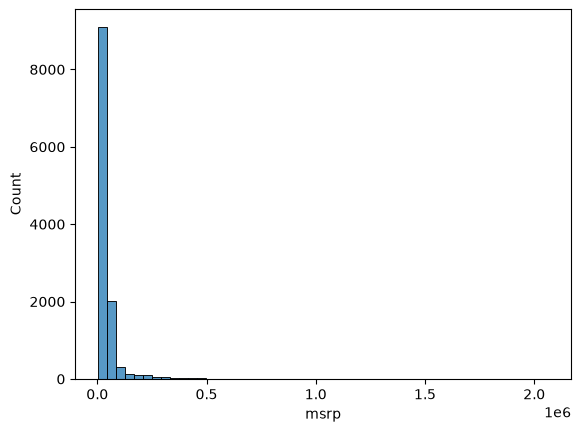

In [13]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

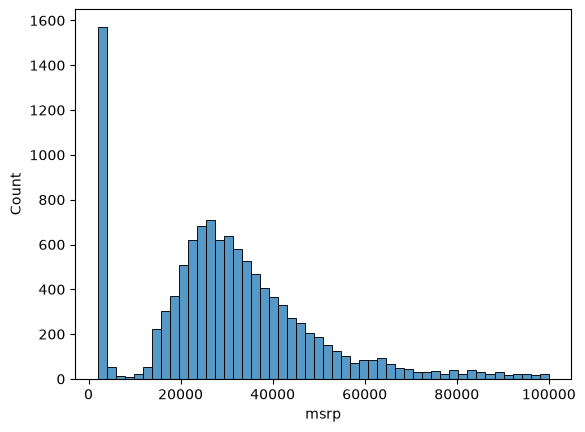

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)


In [15]:
price_logs = np.log1p(df.msrp)   #concise the value of MSRP (target) with log transformation, so that we can see the real shape of data

In [16]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

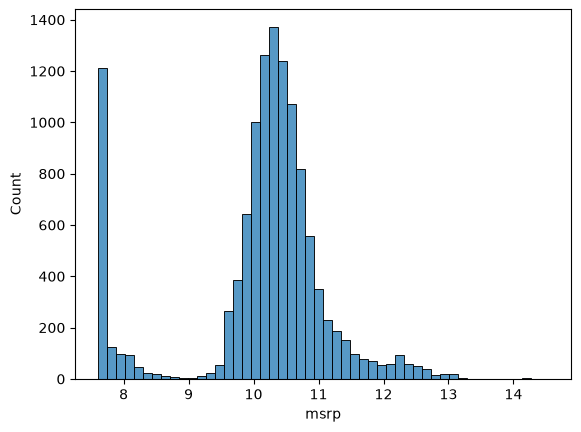

In [17]:
sns.histplot(price_logs, bins=50)

In [18]:
#now the desired data (target) is in shape of a bell curve, which is very ideal shape (normal distribution) 
#for our ml model as tailed distribution confuse model alot. 

In [19]:
# Missing values

df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# Setting up the Validation Framework

In [20]:
#Splitting df into 3 parts -> TRAIN , VALIDATION, TEST 

# RATIO:  TRAIN:VALIDATION:TEST = 60:20:20

In [21]:
n = len(df)
n

11914

In [22]:
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

In [23]:
n_val , n_test , n_train

(2382, 2382, 7150)

In [24]:
# Normally splitting,

In [25]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [26]:
idx = np.arange(n)

In [27]:
np.random.seed(2)
np.random.shuffle(idx)

In [28]:
# reassigning and shuffling using numpy 

In [29]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [30]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [31]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [32]:
# resetting index to normal

In [33]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [34]:
# Extracting target from our splits and also concising the target with log transformation.

In [35]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values) 
y_test = np.log1p(df_test.msrp.values) 

In [36]:
#deleting the target from all 3 splits:

In [37]:
del df_train['msrp']
del df_test['msrp']
del df_val['msrp']

In [38]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

# Linear Regression

***Applying Linear Regression on  a single row:***

In [39]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [40]:
 #Lets perform Linear regression on a single row of data i.e df.iloc[10]

#features of this data we will use for training will be-> [ 'engine_hp' , 'city_mpg' , 'popularity'  ]

#'engine_hp' - Engine Horsepower
#'city_mpg' - Miles per gallon of oil
#'popularity' - social media likebility

#So, our feature matrix for this LR model will be,  x_i =  [453, 11, 86] , where i is df.iloc[10]

#Our Goal -> g(x_i) ≈ y_i

In [41]:
xi = [453, 11, 86]  #feature matrix

In [42]:
# g(xi) = w_0 + (w_1 * x_1) + (w_2 * x_2) + (w_3 * x_3) +.....+ (w_n * x_n) , where (W_0 , w_1, w_2..........w_n) are weights
# and (x_1, x_2, x_3....x_n) is the feature matrix.

In [43]:
# In weights,

# w_0 (Bias / Intercept): The baseline predicted value of the target when all feature inputs are 0.

# and rest of the weights from (w_1 to w_n) represents the influence of each feature on the final target..

In [44]:
#synthetic weights
w0 = 7.17       
w  = [0.01,0.04,0.002]    

In [45]:
def linear_regression(xi):

    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

In [46]:
linear_regression(xi)

12.312

In [47]:
np.expm1(12.312) #we are performing exponential transformation on the predicted target(price), because we performed
# the logarithm transformation on y and this model the synthetic weights are taken according to y.

np.float64(222347.2221101062)

# Linear Regression Vector Form

In [48]:
#Now lets implement logistic regression for a single vector of feature matrix.

#1 implementing this using dot product-> w0 + (dot product of feature vector and weights vector) ,as w0 is additional weight and has no significant xi.

In [49]:
def dot(xi, w):

    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + w[j] * xi[j]
        
    return res

In [50]:
def linear_regression(xi):
    return w0 + dot(xi,w)

In [51]:
#2 Now implementing LR using new approach-> we will dot product new weights and new feature vectors, and the new
# weight vector will be inclusiv of w0, but as soon as we include w0 to new weights vector, the dot product b/w new weights
# and features is not possible, as for dot product the shape of both vector/matrix should be same, so to fix this we will, crete new 
# feature vector where x_0 will be 1 (as w0 * 1 = W0) and add rest of the features to the new feature vector.

In [52]:
w_new = [w0] + w #making new weights vector

In [53]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [54]:
def linear_regression(xi):
    xi = [1] + xi #making new features vector
    return dot(xi,w_new)

In [55]:
linear_regression(xi)

12.312

In [56]:
#3 Now lets implement LR to a custom feature matrix( X ), with the same synthetic weights before. 
# (NOTE: This matrix will have its first column elements as 1, bacause of w0 inclusion in weights vector)

w0 = 7.17
w = [0.01, 0.04, 0.002]

w_new = [w0] + w   #w0 inclusive weights vector

In [57]:
x1 = [1, 148, 24, 1358]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)  # matix X is a square matrix with first col element as 1
X

array([[   1,  148,   24, 1358],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [58]:
def linear_regression(X):
    return X.dot(w_new)  

In [59]:
linear_regression(X) #Linear regression implemented on a matrix, the result is not exactly the real target for that 
# you have perform exponential transformation on this.

array([12.326, 13.552, 12.312])

# Training Linear Regression Model: Normal Equation

In [60]:
#Our goal is: g(X) = Xw ≈ y

#So to achieve our goal of finding y almost equal to Xw, this can help:

#if there exist a X inverse of X then,  we multiply it both side and we will get:

# X inverse . Xw = X inverse . y

# I . w = X inverse . y  (because, X inverse . X = Identity matrix)

# w = X inverse . y (because, Identity matrix . w = w)

#but there's a catch in this approach, which is to find inverse of a matrix, the matrix should be a square matrix.

#And it not sure that the feature matrix we will get will be a square matrix.

#so to make sure that our feature matrix is a square matrix, as most of the time it is a rectangular matrix, we will use GRAM matrix:

#A GRAM matrix is a square matrix and there exist a inverse of it, although it is not sure that the inverse always exist for a GRAM matrix 
#and its inverse depends on few conditions, but we will take this intuition for now that the inverse exist for this GRAM matrix.

# (X transpose . X) inverse . (X transpose) . Xw = (X transpose . X) inverse . (X transpose) . y   where ( (X transpose) . X is a GRAM matrix ) 

# I . w = (X transpose . X) inverse . (X transpose) . y  (because, (X transpose . X) inverse . (X transpose) . X = Identity matrix)

# w = (X transpose . X) inverse . (X transpose) . y 

In [61]:
#Implementing-> w = (X transpose . X) inverse . (X transpose) . y
def train_linear_regression(X,y):
    pass

In [62]:
X = [                          #synthetic feature matrix with added bias
    [1, 148, 24, 1385],
    [1, 132, 25, 2031],
    [1, 453, 11, 86],
    [1, 158, 24, 185],
    [1, 172, 25, 201],
    [1, 413, 22, 140],
    [1, 38,  54, 185],
    [1, 142, 25, 431],
    [1, 353, 31, 86]
]

X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86],
       [   1,  158,   24,  185],
       [   1,  172,   25,  201],
       [   1,  413,   22,  140],
       [   1,   38,   54,  185],
       [   1,  142,   25,  431],
       [   1,  353,   31,   86]])

In [63]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000] #synthetic target vector

In [64]:
XTX = X.T.dot(X)  #(X transpose . X)
XTX

array([[      9,    2009,     241,    4730],
       [   2009,  615871,   45558,  732242],
       [    241,   45558,    7509,  120937],
       [   4730,  732242,  120937, 6372190]])

In [65]:
XTX_inv = np.linalg.inv(XTX)  #(X transpose . X) inverse

In [66]:
w_full = XTX_inv.dot(X.T).dot(y)    # w = (X transpose . X) inverse . (X transpose) . y     

In [67]:
w0 = w_full[0]
w = w_full[1:]

In [68]:
w0, w  #w0 -> base weight, w -> feature weights 

(np.float64(22673.18814744559),
 array([ -10.42869778, -136.5965699 ,   -0.66335436]))

***Packing all inside training fn:***

In [69]:
def train_linear_regression(X, y):
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [70]:
train_linear_regression(X,y)

(np.float64(22673.188147499186),
 array([ -10.42869778, -136.5965699 ,   -0.66335436]))

# Baseline Model for Car Price Prediction Project 

In [71]:
#First lets extract some numerical columns from the training data, as features:

In [72]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [73]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']  #features

In [74]:
df_train[base].fillna(0).sum()  #filling missing values of features as 0.


engine_hp            1770968.0
engine_cylinders       40164.0
highway_mpg           190791.0
city_mpg              141417.0
popularity          11013478.0
dtype: float64

In [75]:
X_train = df_train[base].values  #feature matrix without added bias
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [76]:
X_train = df_train[base].fillna(0).values #filling missing values of features

In [77]:
ones = np.ones(len(df_train))
X_train = np.column_stack([ones, X_train])   #adding vias to the feature matrix
X_train

array([[1.000e+00, 1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03],
       [1.000e+00, 1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02],
       ...,
       [1.000e+00, 2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02],
       [1.000e+00, 5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01],
       [1.000e+00, 2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02]],
      shape=(7150, 6))

In [78]:
y_train #target vector

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [79]:
#and for weights we will use our previously created train_logistic_regression model, which will provide us weight 
#from using our X-train and Y-train data via normal equation.

w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.927257388371917),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908673e-06]))

In [80]:
w_full = np.insert(w, 0, w0)  #making a single weight vector
w_full

array([ 7.92725739e+00,  9.70589522e-03, -1.59103494e-01,  1.43792133e-02,
        1.49441072e-02, -9.06908673e-06])

In [81]:
#PREDICTION:

y_pred = X_train.dot(w_full)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

# RMSE (Root Mean Squared Error)

In [82]:
#To measure the quality of a model, RMSE is used:

#RMSE = (((g(xi) - yi)**2) / m)**0.5

def rmse(y, y_pred):
    error = y-y_pred
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)

In [83]:
rmse(y_train, y_pred) #performing rmse on y_train 

np.float64(0.7554192603920132)

# Computing RMSE on Validation Data

In [84]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']  #features

In [85]:
def prepare_X(df):   #making a fn which will return a feature matrix X with bias added
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [86]:
X_train = prepare_X(df_train)  #feature matrix X-train

w0,w = train_linear_regression(X_train, y_train)  #weights counted using X-train and y-train
w_full = np.insert(w, 0, w0)  #making a single weight vector

X_val = prepare_X(df_val) #feature matrix X-validation

y_pred = X_val.dot(w_full) #model making prediction on X-validation

rmse(y_val, y_pred) #RMSE counted on y-validation and y-prediction (counted using X-validation and y-validation)

np.float64(0.7616530991312638)

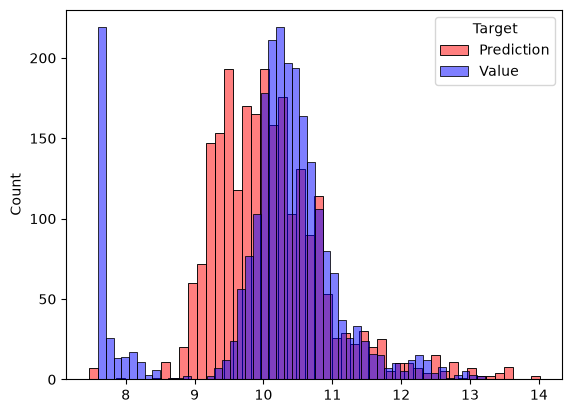

In [87]:
sns.histplot(y_pred, color="red", alpha = 0.5 , bins = 50)
sns.histplot(y_val, color="blue", alpha = 0.5 , bins = 50)
plt.legend(title="Target", labels=["Prediction", "Value"])

# Feature Engineering

In [88]:
#In the section we will add a new feature to our feature matrix:

#Lets add 'year' column as a feature.

df_train.year.max()

np.int64(2017)

In [89]:
#modified this fn which returns feature matrix of a dataframe with bias,
#will now return the feature matrix with bias and the addidtional feature we added.

def prepare_X(df): 
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [90]:
X_train = prepare_X(df_train)

In [91]:
X_train

array([[1.000e+00, 1.480e+02, 4.000e+00, ..., 2.400e+01, 1.385e+03,
        9.000e+00],
       [1.000e+00, 1.320e+02, 4.000e+00, ..., 2.500e+01, 2.031e+03,
        5.000e+00],
       [1.000e+00, 1.480e+02, 4.000e+00, ..., 2.800e+01, 6.400e+02,
        1.000e+00],
       ...,
       [1.000e+00, 2.850e+02, 6.000e+00, ..., 1.700e+01, 5.490e+02,
        2.000e+00],
       [1.000e+00, 5.630e+02, 1.200e+01, ..., 1.300e+01, 8.600e+01,
        3.000e+00],
       [1.000e+00, 2.000e+02, 4.000e+00, ..., 2.200e+01, 8.730e+02,
        0.000e+00]], shape=(7150, 7))

In [92]:
w0,w = train_linear_regression(X_train, y_train)  
w_full = np.insert(w, 0, w0)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 

np.float64(0.517205546106724)

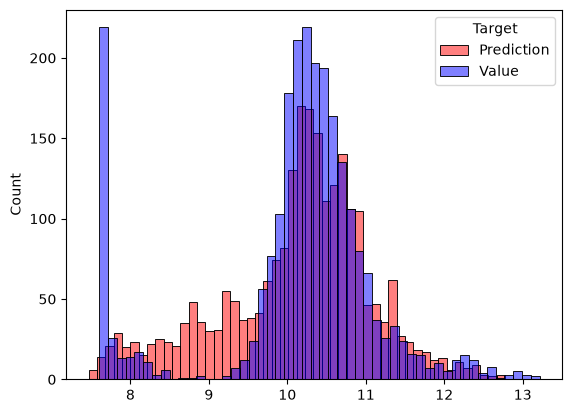

In [93]:
sns.histplot(y_pred, color="red", alpha = 0.5 , bins = 50)
sns.histplot(y_val, color="blue", alpha = 0.5 , bins = 50)
plt.legend(title="Target", labels=["Prediction", "Value"])

In [94]:
#As we can see now adding a new feature 'year' does helped us in RMSE, and now Target predicted
#is in the same range as 'Target value'.

# Categorical Variables

In [95]:
#Now we will use the categorical columns from our df_train, to be used as features in our X-train.
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

***<u>adding (number of doors) to features</u>***

In [96]:
df_train.number_of_doors

0       2.0
1       4.0
2       4.0
3       3.0
4       4.0
       ... 
7145    2.0
7146    2.0
7147    4.0
7148    4.0
7149    4.0
Name: number_of_doors, Length: 7150, dtype: float64

In [97]:
#as you can see there are 3 types of doors in the cars: 1 , 2 , 3:

#lets prepare them to be converted in  a numerical column, so they can be used as features:

In [98]:
def prepare_X(df): 
    df = df.copy() #making a copy so original df remain intact
    df['age'] = 2017 - df.year #making new col 'age'
    features = base.copy()  #making a base- features copy
    features.append('age')  #adding 'age' as a feature

    for v in [2, 3, 4]:
        df["num_doors_%s" % v] = (df.number_of_doors == v).astype("int")  #making individual 'number of doors' column
        features.append('num_doors_%s' % v) #adding those columns as feature
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [99]:
X_train = prepare_X(df_train)
w0,w = train_linear_regression(X_train, y_train)  
w_full = np.insert(w, 0, w0)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 

np.float64(0.5157995641500701)

***<u>adding (popular car makers) to features</u>***


In [100]:
makes = list(df_train.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [101]:
def prepare_X(df): 
    df = df.copy() #making a copy so original df remain intact
    df['age'] = 2017 - df.year 
    features = base.copy()  
    features.append('age')  

    for v in [2, 3, 4]:
        df["num_doors_%s" % v] = (df.number_of_doors == v).astype("int")  
        features.append('num_doors_%s' % v) 

    for v in makes:
        df["make_%s" % v] = (df.make == v).astype("int")  
        features.append('make_%s' % v) 
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [102]:
X_train = prepare_X(df_train)
w0,w = train_linear_regression(X_train, y_train)  
w_full = np.insert(w, 0, w0)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 

np.float64(0.5076038849522709)

***<u>adding (more categorical variable's top values) to features</u>***


In [103]:
#made a list of all categorical column we want as features:

categorical_variables = [ 'make', 'engine_fuel_type', 'transmission_type', 
                          'driven_wheels', 'market_category', 'vehicle_size',
                        'vehicle_style']

In [104]:
#made a dictionary, which store (colummn name) as key and (top 5 value of column) as value:

categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [105]:
def prepare_X(df): 
    df = df.copy() #making a copy so original df remain intact
    df['age'] = 2017 - df.year 
    features = base.copy()  
    features.append('age')  

    for v in [2, 3, 4]:
        df["num_doors_%s" % v] = (df.number_of_doors == v).astype("int")  
        features.append('num_doors_%s' % v) 

    for c,values in categories.items():  #adds every column as features
        for v in values:
            df["%s_%s" % (c, v)] = (df[c] == v).astype("int")  
            features.append("%s_%s" % (c, v)) 
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    ones = np.ones(len(df))
    X = np.column_stack([ones,X])
    return X

In [106]:
X_train = prepare_X(df_train)
w0,w = train_linear_regression(X_train, y_train)  
w_full = np.insert(w, 0, w0)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 

np.float64(0.4565170136206447)

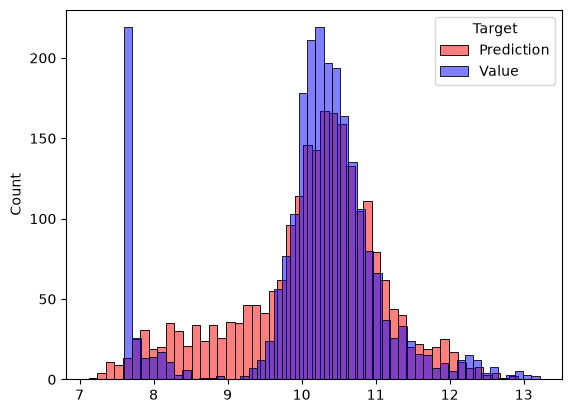

In [107]:
sns.histplot(y_pred, color="red", alpha = 0.5 , bins = 50)
sns.histplot(y_val, color="blue", alpha = 0.5 , bins = 50)
plt.legend(title="Target", labels=["Prediction", "Value"])

# Regularization

In [108]:
# Even though our model is significantly improved,we will still apply Ridge (L_2) regularization as soon as we will add
#new features to the the feature matrix X-train, because sometimes in the feature matrix X-train two or more than features 
#become same, and for these cases the inverse of (X_transpose . X ) doesnt exist.

#More about Regularization:

#Adding excessive features can sometimes backfire by spiking validation RMSE due to overfitting, 
#multicollinearity, and the curse of dimensionality. Because high-dimensional models tend to
#memorize training noise and suffer from volatile coefficients, regularization is essential right after feature expansion. 
#By applying Ridge (L_2) or Lasso (L_1) penalties, you mathematically constrain overly large weights, 
#dampening noisy variables and keeping model complexity under control for stable, reliable predictions.

In [109]:
def train_linear_regression_reg(X, y, r=0.001):
    XTX = X.T.dot(X)
    
    XTX = XTX + r * np.eye(XTX.shape[0]) #we have added synthetic (alpha-> r) in the form of identity matrix, to avoid duplicate values of features.
    
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full

In [110]:
X_train = prepare_X(df_train)

w_full = train_linear_regression_reg(X_train, y_train, r=0.01)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 

np.float64(0.4565219899730939)

# Tuning the Model

In [111]:
#Now we will try to find the best value of alpha/ Regularization parameter for our model:

for r in [0.0, 0.00001, 0.001, 0.1, 1, 10]:  #sample of different alpha's we can take, according to the lowest RMSE:
    X_train = prepare_X(df_train)
    
    w_full = train_linear_regression_reg(X_train, y_train, r=r)  
    
    X_val = prepare_X(df_val) 
    
    y_pred = X_val.dot(w_full)
    
    score = rmse(y_val, y_pred) 

    print(r, " " , w_full[0], " ", score)
    

0.0   12.366425692960744   0.4565170136206447
1e-05   11.427330382983913   0.4565170185493079
0.001   6.2856449695573975   0.4565175085410508
0.1   6.191209454316635   0.45656927611363196
1   5.634897329673816   0.45722043121459205
10   4.283980761317335   0.4701456904361561


In [112]:
#as we can see we already have lowest RMSE without Regularization alpha.
#None the less, we will still take some alpha having the lowest RMSE.
#So we will choose r = 0.00001

X_train = prepare_X(df_train)

w_full = train_linear_regression_reg(X_train, y_train, r=0.00001)  

X_val = prepare_X(df_val) 

y_pred = X_val.dot(w_full)

rmse(y_val, y_pred) 


np.float64(0.4565170185493079)

# Using the Final Model:

In [113]:
#Now that the Validation of our Price prediction Linear Regression Model is completed:

#Lets make a Final Model where we will train it on data:
#df_Full_Train = df_train + df_validation and test it on -> X-test and y-test.

In [114]:
df_full_train = pd.concat([df_train, df_val])

In [115]:
df_full_train = df_full_train.reset_index(drop=True)

In [116]:
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436


In [117]:
X_full_train = prepare_X(df_full_train)

In [118]:
X_full_train

array([[  1., 148.,   4., ...,   1.,   0.,   0.],
       [  1., 132.,   4., ...,   0.,   0.,   1.],
       [  1., 148.,   4., ...,   0.,   0.,   1.],
       ...,
       [  1., 332.,   8., ...,   0.,   0.,   0.],
       [  1., 148.,   4., ...,   0.,   0.,   0.],
       [  1., 290.,   6., ...,   0.,   0.,   0.]], shape=(9532, 42))

In [119]:
y_full_train = np.concatenate([y_train, y_val])

In [120]:
y_full_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(9532,))

In [121]:
r= 0.00001
w_full = train_linear_regression_reg(X_full_train, y_full_train, r=r)  


In [122]:
w_full

array([ 1.17284619e+01,  1.52501167e-03,  1.18183863e-01, -6.66275369e-03,
       -5.33572506e-03, -4.87603301e-05, -9.69102081e-02, -7.94123368e-01,
       -8.92378853e-01, -6.36604123e-01, -4.14318130e-02,  1.75561763e-01,
       -5.82377677e-04, -1.00561906e-01, -9.27558006e-02, -4.66934476e-01,
        7.97940610e-02, -3.16123296e-01, -5.52057668e-01, -7.90074575e-02,
       -2.85432515e-01, -4.60741124e-01, -2.31158602e-01,  1.27202836e+00,
       -8.70776509e-01, -9.51302121e-02, -1.94431469e-01, -1.07259284e-01,
       -1.79259476e-01, -9.70581139e-02,  3.73034565e-02, -5.81759176e-02,
       -2.35911535e-02, -1.19300076e-02, -1.10640338e-01, -2.25009792e-01,
       -2.40430277e-01, -5.00782172e-02,  5.62147442e-02,  1.84795568e-01,
        3.32645379e-01, -1.58805556e-01])

In [123]:
X_test = prepare_X(df_test) 

y_pred = X_test.dot(w_full)

score = rmse(y_test, y_pred) 
score 

np.float64(0.4517745111311895)

In [124]:
#the RMSE of our final Model is same as our previous model, meaning our model is working perfectly fine.
#now that our final model is ready, lets test it a car data: 

df_test.iloc[20]

make                            toyota
model                           sienna
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        266.0
engine_cylinders                   6.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category                    NaN
vehicle_size                     large
vehicle_style        passenger_minivan
highway_mpg                         25
city_mpg                            18
popularity                        2031
Name: 20, dtype: object

In [125]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [126]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [127]:
X_small = prepare_X(df_small)

In [128]:
y_pred = X_small.dot(w_full)
y_pred = y_pred[0]
y_pred

np.float64(10.46266012791674)

In [129]:
round(np.expm1(y_pred),3)

np.float64(34983.491)

In [130]:
round(np.expm1(y_test[20]),3)

np.float64(35000.0)

In [131]:
#as you can see our model predicted the price pretty accurately.
#Real Price of Car-> 34983.491 , Predicted Price-> 35000.0